# Variant 2 visit distribution

Roll out **DQN v8.13.2** and **DQN v8.5.31** on the same 100 variant-2 test episodes. Color depth represents the number of times the agent occupied each traversable cell; blocked cells are pure black. The initial position of every episode is included.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import torch

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'statistic' else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import rainbow_dqn
from environment_v5 import Environment_v5
from environment_v13 import Environment_v13

DATA_DIR = PROJECT_ROOT / 'data'
MODEL_ROOT = PROJECT_ROOT / 'models2'
VARIANT = 2
NUM_TEST_EPISODES = 100

RUNS = [
    {
        'name': 'DQN v8.13.2 + env13',
        'short_name': 'v8.13.2',
        'env_class': Environment_v13,
        'model_path': MODEL_ROOT / 'DQN_v8.13.2_variant_2.pt',
    },
    {
        'name': 'DQN v8.5.31 + env5',
        'short_name': 'v8.5.31',
        'env_class': Environment_v5,
        'model_path': MODEL_ROOT / 'DQN_v8.5.31_variant_2.pt',
    },
]

print(f'Project root: {PROJECT_ROOT}')
print(f'Test episodes: {NUM_TEST_EPISODES}')

2026-07-14 10:42:15.259998: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Project root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team
Test episodes: 100


In [2]:
def load_policy(env, model_path):
    policy = rainbow_dqn.DQN_v8(env)
    policy.device = torch.device('cpu')
    policy.support = policy.support.to(policy.device)
    policy.q_network.to(policy.device)
    policy.target_network.to(policy.device)
    state_dict = torch.load(model_path, map_location=policy.device)
    policy.q_network.load_state_dict(state_dict)
    policy.q_network.eval()
    policy.epsilon = 0
    return policy


def rollout_visit_counts(run, episode_ids):
    env = run['env_class'](variant=VARIANT, data_dir=str(DATA_DIR))
    policy = load_policy(env, run['model_path'])
    counts = np.zeros((env.vertical_cell_count, env.horizontal_cell_count), dtype=np.int64)

    for episode_id in episode_ids:
        env.test_episodes = [int(episode_id)]
        obs = env.reset('testing')
        counts[env.agent_loc] += 1  # include the initial position

        for _ in range(env.episode_steps):
            action = int(policy.select_action(obs))
            _, obs, done = env.step(action)
            counts[env.agent_loc] += 1
            if done:
                break

    eligible = set(env.eligible_cells)
    blocked = [
        (row, col)
        for row in range(env.vertical_cell_count)
        for col in range(env.horizontal_cell_count)
        if (row, col) not in eligible
    ]
    return counts, blocked


episode_ids = pd.read_csv(DATA_DIR / 'variant_2' / 'test_episodes.csv')['test_episodes'].head(NUM_TEST_EPISODES)
visit_counts = {}
blocked_cells = None

for run in RUNS:
    print(f"Rolling out {run['name']}...")
    counts, run_blocked_cells = rollout_visit_counts(run, episode_ids)
    visit_counts[run['short_name']] = counts
    blocked_cells = run_blocked_cells if blocked_cells is None else blocked_cells

pd.DataFrame({
    'model': [run['short_name'] for run in RUNS],
    'recorded_positions': [visit_counts[run['short_name']].sum() for run in RUNS],
    'visited_traversable_cells': [(visit_counts[run['short_name']] > 0).sum() for run in RUNS],
})

Rolling out DQN v8.13.2 + env13...
Using device: cpu
Rolling out DQN v8.5.31 + env5...
Using device: cpu


,model,recorded_positions,visited_traversable_cells
0,v8.13.2,20100,13
1,v8.5.31,20100,12


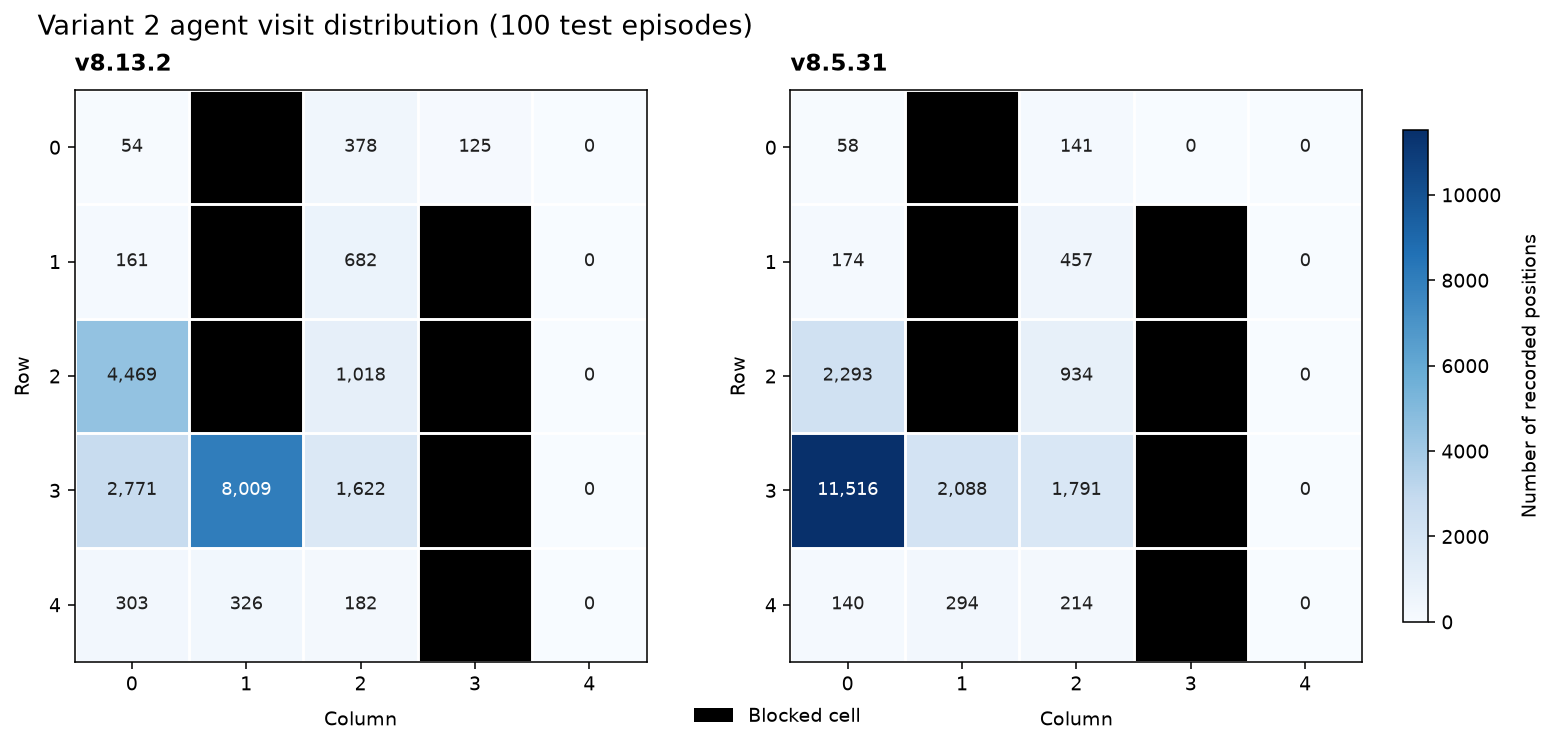

In [3]:
# Shared scale makes the two models directly comparable.
vmax = max(grid.max() for grid in visit_counts.values())
visit_cmap = LinearSegmentedColormap.from_list(
    'visit_blue', ['#f7fbff', '#c6dbef', '#6baed6', '#2171b5', '#08306b']
)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), dpi=140, constrained_layout=True)
images = []

for ax, run in zip(axes, RUNS):
    grid = visit_counts[run['short_name']]
    display_grid = np.ma.array(grid, mask=False)
    for row, col in blocked_cells:
        display_grid.mask[row, col] = True

    cmap = visit_cmap.copy()
    cmap.set_bad('black')
    image = ax.imshow(display_grid, cmap=cmap, vmin=0, vmax=vmax, interpolation='nearest')
    images.append(image)

    ax.set_title(run['short_name'], loc='left', pad=10, fontweight='bold')
    ax.set_xlabel('Column', labelpad=8)
    ax.set_ylabel('Row', labelpad=8)
    ax.set_xticks(range(grid.shape[1]))
    ax.set_yticks(range(grid.shape[0]))
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=1.5)
    ax.tick_params(which='minor', bottom=False, left=False)

    for row in range(grid.shape[0]):
        for col in range(grid.shape[1]):
            if (row, col) in blocked_cells:
                continue
            value = grid[row, col]
            text_color = 'white' if vmax and value > 0.48 * vmax else '#202020'
            ax.text(col, row, f'{value:,}', ha='center', va='center', color=text_color, fontsize=9)

colorbar = fig.colorbar(images[0], ax=axes, shrink=0.86, pad=0.03)
colorbar.set_label('Number of recorded positions', labelpad=10)
fig.legend(handles=[Patch(facecolor='black', label='Blocked cell')], loc='lower center', frameon=False)
fig.suptitle('Variant 2 agent visit distribution (100 test episodes)', fontsize=14, x=0.06, ha='left')
plt.show()